In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def plot_learning_curves(csv_path, fixed_param_filter, compare_param=None, plot_train=False):
    """
    Plots Loss curves (mean + standard deviation) based on history CSV files.
    
    Parameters:
    - csv_path: Path to the CSV file (e.g., 'resnet18_bs_history.csv').
    - fixed_param_filter: String used to filter the data. Allows specifying e.g., 
                          a specific LR to avoid plotting everything at once (e.g., 'LR=1e-04').
    - compare_param: Name of the hyperparameter to compare on the plot 
                     (e.g., 'BS', 'DROPOUT'). Used to create a readable legend.
    - plot_train: Usually, only Validation Loss is plotted on comparative charts. 
                  Set to True to force plotting Train Loss as well (dashed lines).
    """
    df = pd.read_csv(csv_path)
    
    configs = [c for c in df['config'].unique() if fixed_param_filter in c]
    
    if not configs:
        print(f"No configurations matching the filter: '{fixed_param_filter}'")
        return
        
    plt.figure(figsize=(10, 6))
    colors = plt.cm.tab10.colors
    
    for idx, config in enumerate(configs):
        color = colors[idx % len(colors)]
        df_conf = df[df['config'] == config]
        
        grouped = df_conf.groupby('epoch').agg({
            'train_loss': ['mean', 'std'],
            'val_loss': ['mean', 'std']
        }).reset_index()
        
        epochs = grouped['epoch']
        
        label_name = config
        if compare_param:
            match = re.search(fr'{compare_param}=([^\_]+)', config)
            if match:
                label_name = f"{compare_param}={match.group(1)}"
        
        val_mean = grouped['val_loss']['mean']
        val_std = grouped['val_loss']['std']
        
        plt.plot(epochs, val_mean, label=f"Val: {label_name}", color=color, linewidth=2)
        plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color=color, alpha=0.2)
        
        if plot_train or len(configs) == 1:
            train_mean = grouped['train_loss']['mean']
            train_std = grouped['train_loss']['std']
            
            plt.plot(epochs, train_mean, label=f"Train: {label_name}", 
                     color=color, linestyle='--', linewidth=2)
            plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, 
                             color=color, alpha=0.1)

    title = f"Hyperparameter Comparison: {compare_param}" if compare_param else f"Learning Curve: {fixed_param_filter}"
    if compare_param:
        title += f"\n(Fixed parameters: {fixed_param_filter})"
        
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

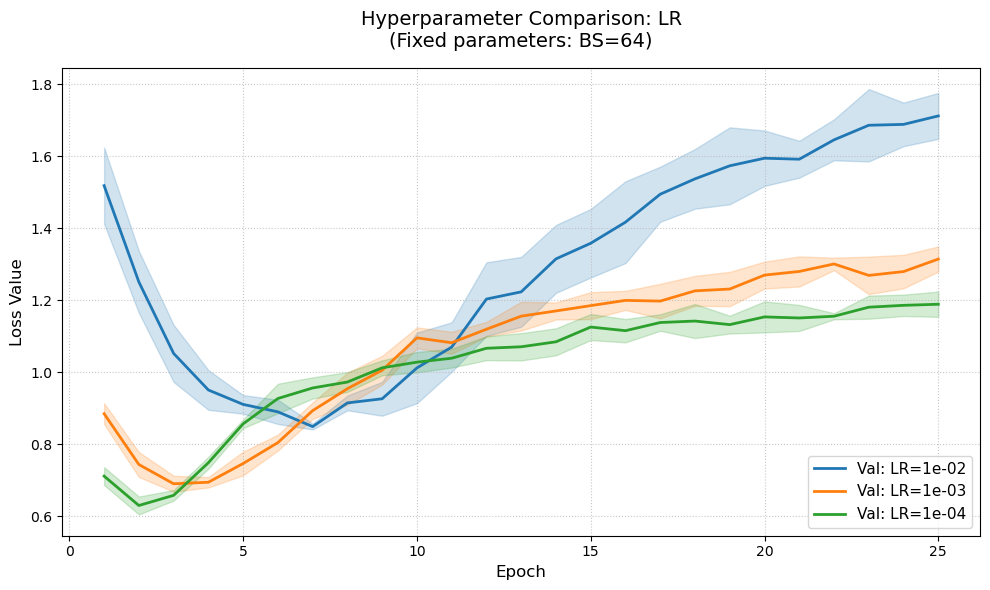

In [30]:
plot_learning_curves(
    csv_path='./resnet18/results/baseline/resnet18_lr_history.csv', 
    fixed_param_filter='BS=64',  
    compare_param='LR',           
    plot_train=False              
)

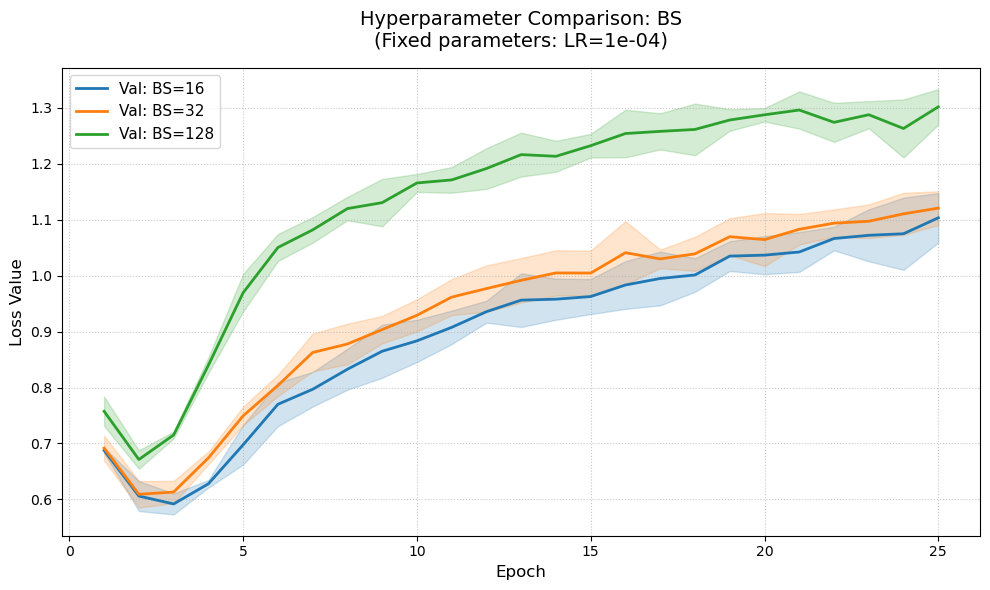

In [ ]:
plot_learning_curves(
    csv_path='./resnet18/results/baseline/resnet18_bs_history.csv', 
    fixed_param_filter='LR=1e-04',
    compare_param='BS',            
    plot_train=False
)

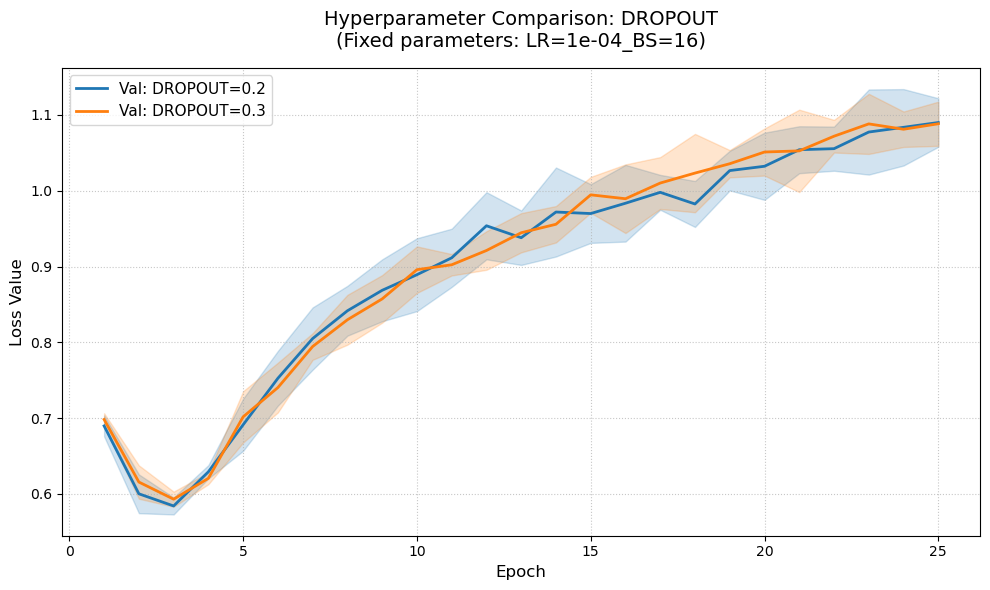

In [ ]:
plot_learning_curves(
    csv_path='./resnet18/results/baseline/resnet18_dropout_history.csv', 
    fixed_param_filter='LR=1e-04_BS=16',     
    compare_param='DROPOUT',                  
    plot_train=False                          
)

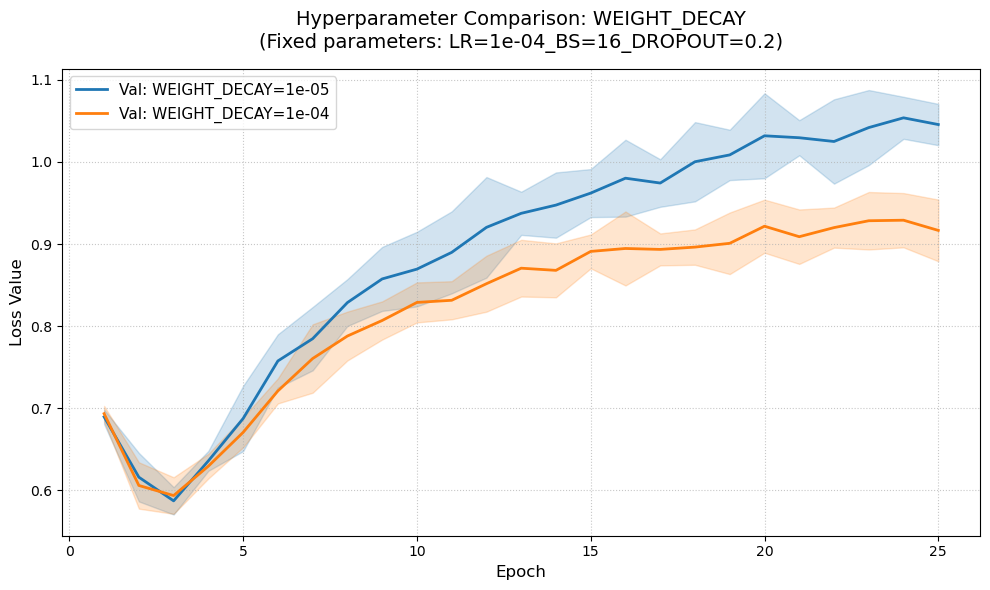

In [ ]:
plot_learning_curves(
    csv_path='./resnet18/results/baseline/resnet18_weight_decay_history.csv', 
    fixed_param_filter='LR=1e-04_BS=16_DROPOUT=0.2',
    compare_param='WEIGHT_DECAY'
)